# Titanic Survival Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme()
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
file_name = "titanic.csv"
df = pd.read_csv(file_name)

print("Titanic dataset loaded successfully.")
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")

display(df.head())

Titanic dataset loaded successfully.
Dataset shape: 891 rows x 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print("Column Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
display(df.isnull().sum().to_frame("Missing Values"))

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Missing Values:


,Missing Values
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
if "Age" in df.columns:
    df["Age"] = df["Age"].fillna(df["Age"].median())

if "Fare" in df.columns:
    df["Fare"] = df["Fare"].fillna(df["Fare"].median())

if "Embarked" in df.columns and df["Embarked"].isnull().any():
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print("Data cleaning completed.")
display(df.isnull().sum().to_frame("Missing Values"))

Data cleaning completed.


,Missing Values
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Overall Survival

Total passengers: 891
Passengers survived: 342
Overall survival rate: 38.38%


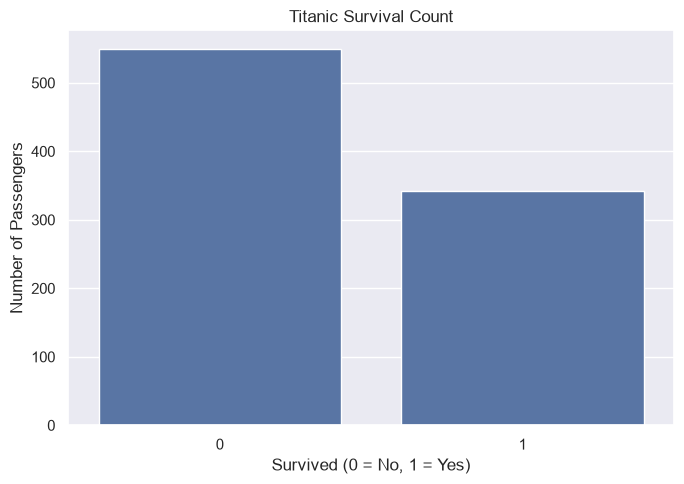

In [21]:
survival_rate = df["Survived"].mean() * 100

print(f"Total passengers: {len(df)}")
print(f"Passengers survived: {df['Survived'].sum()}")
print(f"Overall survival rate: {survival_rate:.2f}%")

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Survived")
plt.title("Titanic Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()

## Survival by Gender

,Survival Rate (%)
Sex,
female,74.203822
male,18.890815


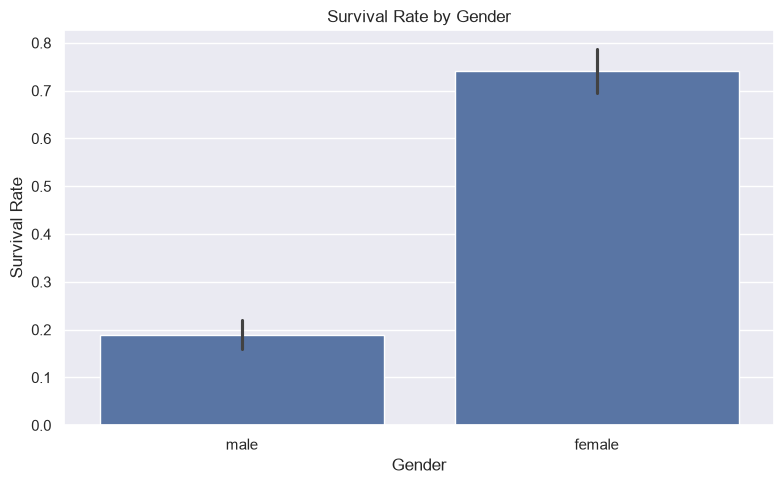

In [22]:
gender_survival = df.groupby("Sex")["Survived"].mean().mul(100).sort_values(ascending=False)
display(gender_survival.rename("Survival Rate (%)").to_frame())

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Sex", y="Survived")
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()

## Survival by Passenger Class

,Survival Rate (%)
Pclass,
1,62.962963
2,47.282609
3,24.236253


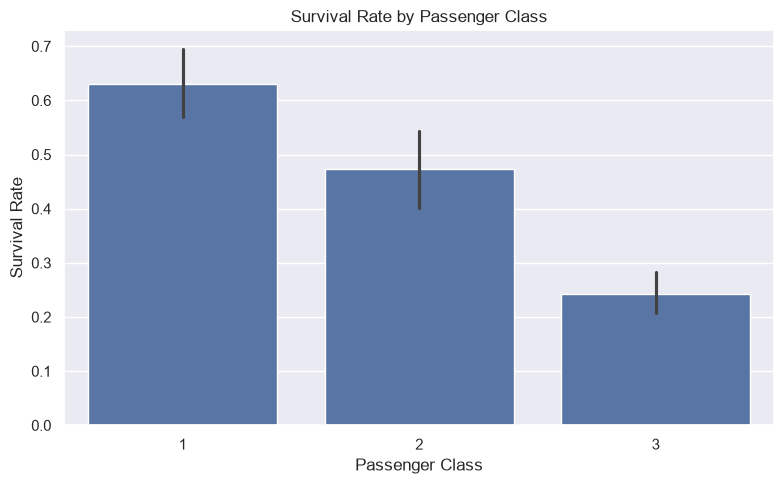

In [23]:
class_survival = df.groupby("Pclass")["Survived"].mean().mul(100)
display(class_survival.rename("Survival Rate (%)").to_frame())

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Pclass", y="Survived")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()

## Survival by Class and Gender

,Pclass,Sex,Survival Rate (%)
0,1,female,96.808511
1,1,male,36.885246
2,2,female,92.105263
3,2,male,15.740741
4,3,female,50.000000
5,3,male,13.544669


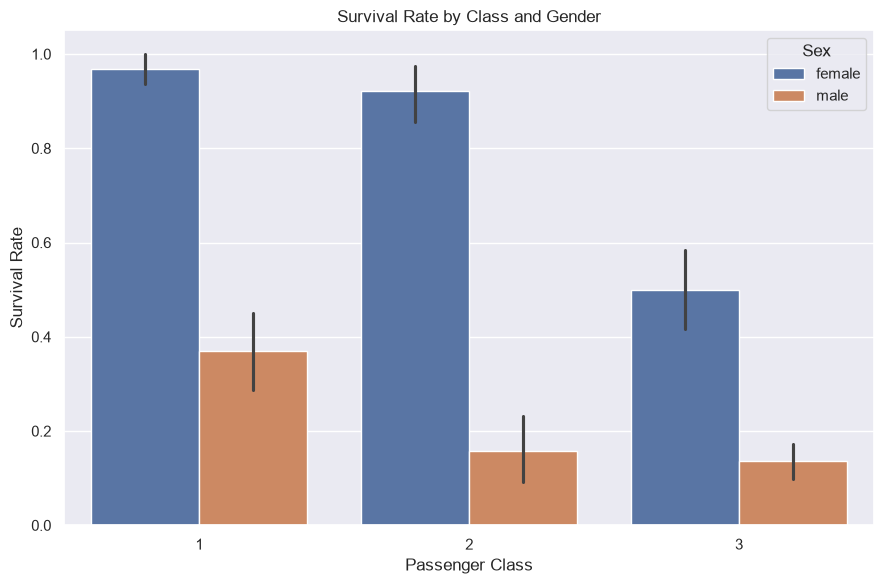

In [24]:
display(
    df.groupby(["Pclass", "Sex"])["Survived"]
      .mean()
      .mul(100)
      .rename("Survival Rate (%)")
      .reset_index()
)

plt.figure(figsize=(9, 6))
sns.barplot(data=df, x="Pclass", y="Survived", hue="Sex")
plt.title("Survival Rate by Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()

## Age Analysis

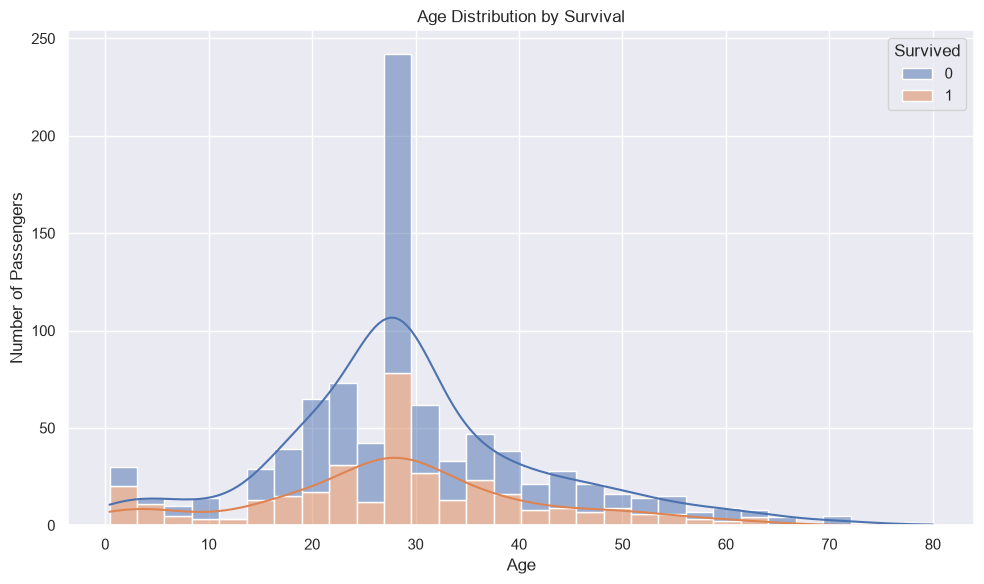

,Survival Rate (%)
Age_Group,
Child,57.971014
Teenager,42.857143
Young Adult,35.327103
Adult,40.000000
Senior,22.727273


In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=True, multiple="stack")
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.show()

bins = [0, 12, 18, 35, 60, 100]
labels = ["Child", "Teenager", "Young Adult", "Adult", "Senior"]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

age_survival = (
    df.groupby("Age_Group", observed=False)["Survived"]
      .mean()
      .mul(100)
)

display(age_survival.rename("Survival Rate (%)").to_frame())

plt.figure(figsize=(9, 5))
sns.barplot(x=age_survival.index, y=age_survival.values)
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Fare Analysis

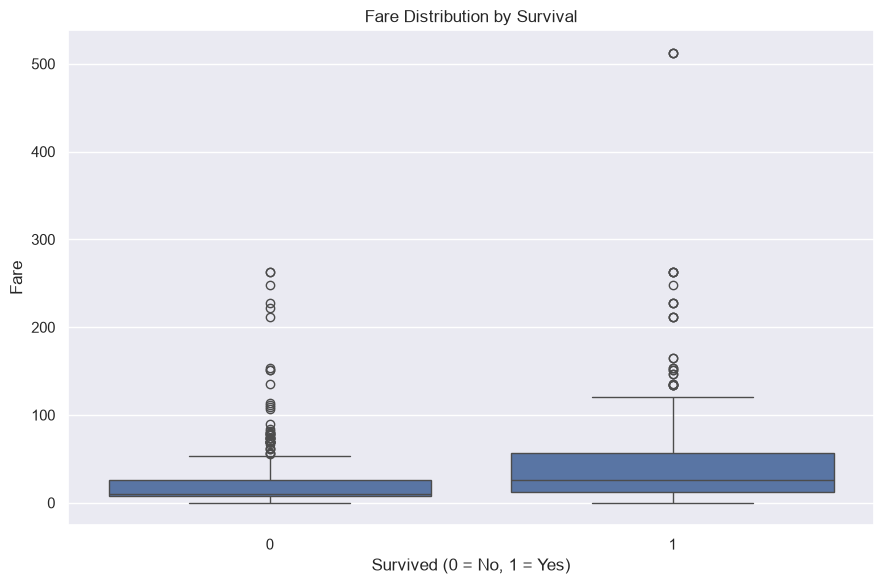

In [26]:
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x="Survived", y="Fare")
plt.title("Fare Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()

## Embarkation Analysis

,Survival Rate (%)
Embarked,
C,55.357143
Q,38.961039
S,33.900929


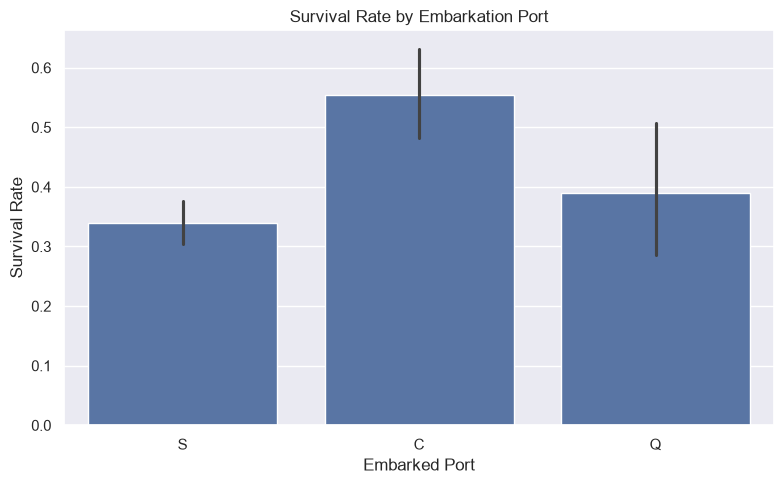

In [27]:
if "Embarked" in df.columns:
    embarked_survival = df.groupby("Embarked")["Survived"].mean().mul(100)
    display(embarked_survival.rename("Survival Rate (%)").to_frame())

    plt.figure(figsize=(8, 5))
    sns.barplot(data=df, x="Embarked", y="Survived")
    plt.title("Survival Rate by Embarkation Port")
    plt.xlabel("Embarked Port")
    plt.ylabel("Survival Rate")
    plt.tight_layout()
    plt.show()

## Family Size Analysis

,Survival Rate (%)
FamilySize,
1,30.353818
2,55.279503
3,57.843137
4,72.413793
5,20.000000
6,13.636364
7,33.333333
8,0.000000
11,0.000000


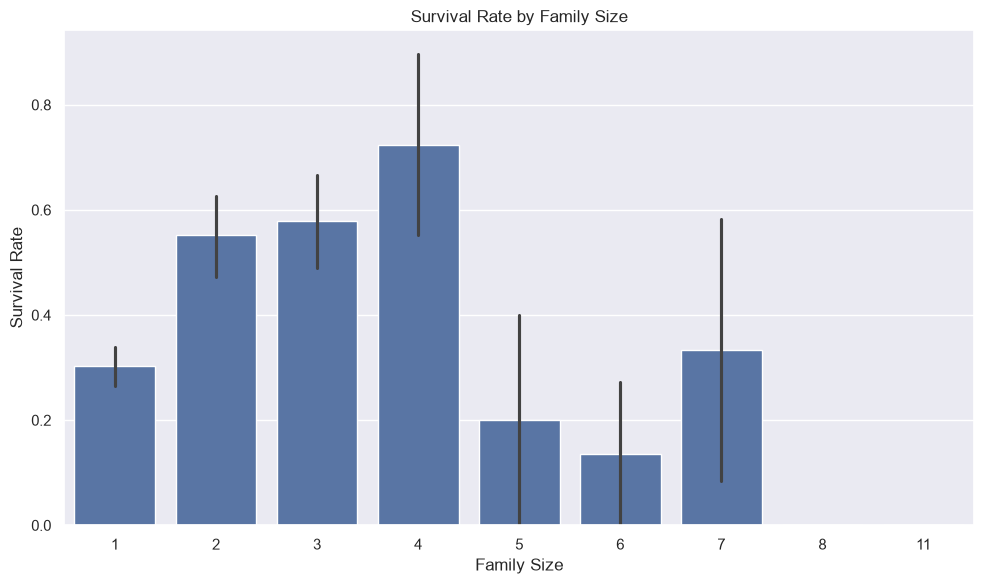

In [28]:
if "SibSp" in df.columns and "Parch" in df.columns:
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    family_survival = df.groupby("FamilySize")["Survived"].mean().mul(100)
    display(family_survival.rename("Survival Rate (%)").to_frame())

    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x="FamilySize", y="Survived")
    plt.title("Survival Rate by Family Size")
    plt.xlabel("Family Size")
    plt.ylabel("Survival Rate")
    plt.tight_layout()
    plt.show()

## Correlation Heatmap

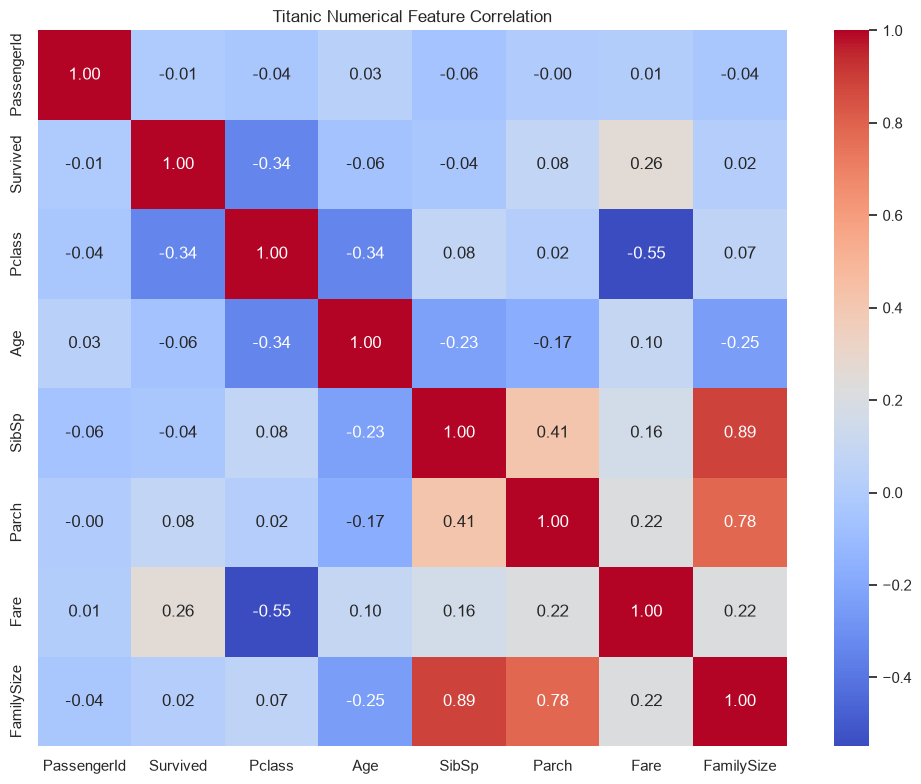

In [29]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Titanic Numerical Feature Correlation")
plt.tight_layout()
plt.show()

## insight


The Titanic dataset shows that passenger characteristics were associated with survival.

- Gender had a strong relationship with survival.
- Passenger class was an important factor.
- Age groups showed differences in survival.
- Fare can be compared with survival outcomes.
- Family size and embarkation point provide additional insights.

**Note:** The analysis identifies associations in the dataset and does not by itself prove causation.